# Portfolio De-Risking Decision Report

This notebook converts the dated portfolio weights and constituent prices into a practical PM risk-management workflow. It starts with the current portfolio, diagnoses the source of risk, applies increasingly targeted controls, and ends with a comparison of feasible de-risking decisions.

The central question is not simply **how much risk should be removed?** It is **which risk should be removed, from which positions, under which constraints, and with what impact on return, Sharpe, drawdown, and factor exposure?**

## Decision Flow

1. Rebuild the portfolio from the authoritative time-series weights and 2015-present constituent prices.
2. Measure Barra-style factor exposure and identify limit breaches.
3. Apply the SPX drawdown and volatility overlay when the risk is broad and systemic.
4. Use MCTR to identify positions that contribute disproportionately to portfolio volatility.
5. Use constrained optimization to generate alternative reallocations, including protected holdings.
6. Compare each decision over 2025-2026 against the baseline and SPX benchmark.

The factor inputs are public ETF proxies rather than licensed Barra data. Results are research estimates and should be validated out of sample before trading.

Rebuilt portfolio summary:
Total return         8.9017
Max drawdown        -0.4743
Annualized return    0.2183
Annualized vol       0.3391
dtype: float64


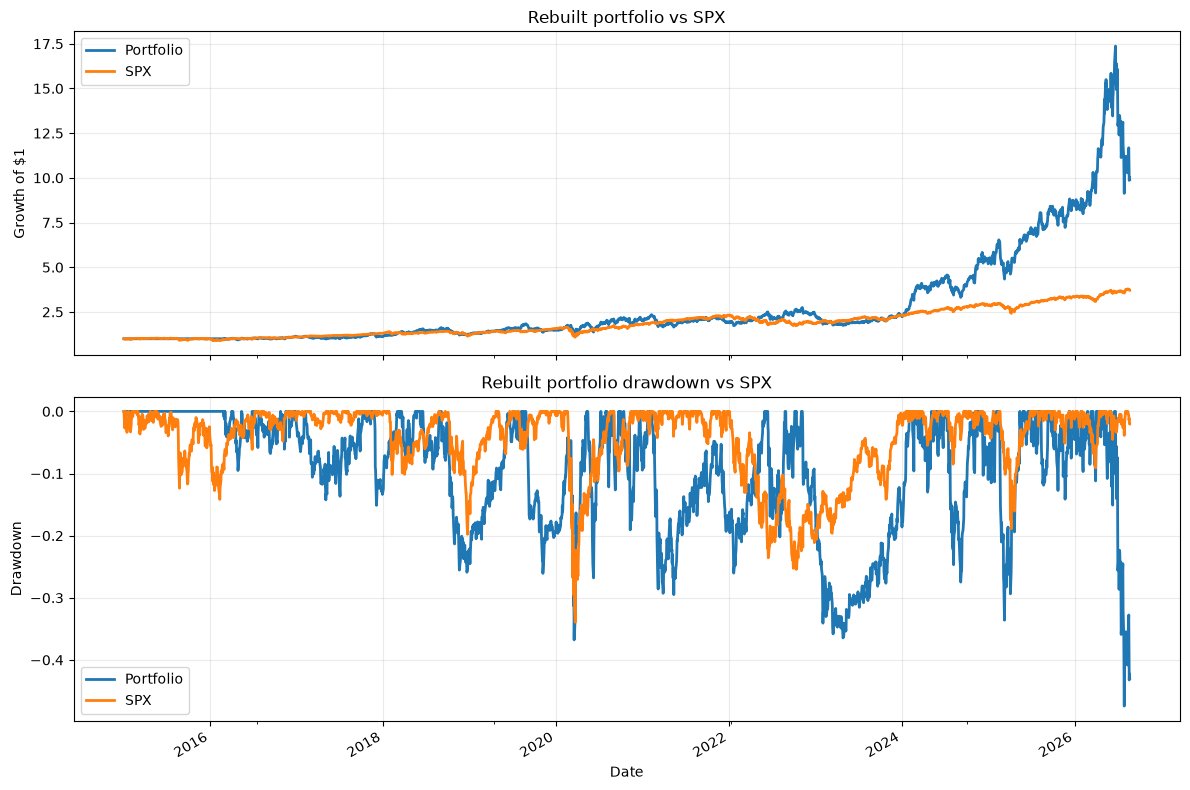

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

risk_dir = Path.cwd()

# Load the historical portfolio weight matrix with its saved rebalance-date index.
weight_file = risk_dir / "Portfolio_weight.csv"
weights = pd.read_csv(weight_file, index_col=0)
weights.index = pd.to_datetime(weights.index)
weights = weights.sort_index()

# The constituent price history starts in 2015, so use that available overlap.
price_file = risk_dir / "sp500_constituent_prices.csv"
if price_file.exists():
    prices = pd.read_csv(price_file, index_col=0)
    prices.index = pd.to_datetime(prices.index)
else:
    prices = yf.download(
        list(weights.columns),
        start="2015-01-01",
        end=(weights.index.max() + pd.Timedelta(days=30)).strftime("%Y-%m-%d"),
        auto_adjust=True,
        progress=False,
        group_by="ticker",
        threads=True,
    )
    if isinstance(prices.columns, pd.MultiIndex):
        prices = prices["Close"] if "Close" in prices else prices.xs("Close", axis=1, level=1)
    else:
        prices = prices["Close"] if "Close" in prices.columns else prices
    prices = prices.loc[:, list(weights.columns)]
    prices = prices.ffill().bfill()

prices = prices.sort_index()
prices = prices.loc[prices.index >= pd.Timestamp("2015-01-01")]
prices = prices.reindex(columns=weights.columns)

# Carry each monthly rebalance forward to each daily date before computing returns.
daily_weights = weights.reindex(prices.index, method="ffill").ffill()
daily_weights = daily_weights.reindex(columns=prices.columns).fillna(0.0)

returns = prices.pct_change().fillna(0.0)
portfolio_return = (returns * daily_weights).sum(axis=1)
portfolio_equity = pd.Series((1 + portfolio_return).cumprod(), index=portfolio_return.index, name="Portfolio")

# Compare with SPX.
spx = yf.download(
    "^GSPC",
    start=portfolio_equity.index.min().strftime("%Y-%m-%d"),
    end=portfolio_equity.index.max().strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    threads=False,
)["Close"]
if isinstance(spx, pd.DataFrame):
    spx = spx.squeeze("columns")
spx = spx.reindex(portfolio_equity.index).ffill().bfill()
spx_returns = spx.pct_change().fillna(0.0)
spx_equity = pd.Series((1 + spx_returns).cumprod(), index=spx_returns.index, name="SPX")

comparison = pd.DataFrame({"Portfolio": portfolio_equity, "SPX": spx_equity}).dropna()
comparison = comparison / comparison.iloc[0]

portfolio_metrics = pd.Series({
    "Total return": comparison["Portfolio"].iloc[-1] - 1,
    "Max drawdown": (comparison["Portfolio"] / comparison["Portfolio"].cummax() - 1).min(),
    "Annualized return": (comparison["Portfolio"].iloc[-1]) ** (252 / len(comparison)) - 1,
    "Annualized vol": portfolio_return.std() * np.sqrt(252),
})

print("Rebuilt portfolio summary:")
print(portfolio_metrics.round(4))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
comparison["Portfolio"].plot(
    ax=axes[0], linewidth=2, label="Portfolio", title="Rebuilt portfolio vs SPX"
)
comparison["SPX"].plot(ax=axes[0], linewidth=2, label="SPX")
axes[0].set_ylabel("Growth of $1")
axes[0].grid(alpha=0.25)
axes[0].legend()

portfolio_drawdown = comparison["Portfolio"] / comparison["Portfolio"].cummax() - 1
spx_drawdown = comparison["SPX"] / comparison["SPX"].cummax() - 1
pd.concat({"Portfolio": portfolio_drawdown, "SPX": spx_drawdown}, axis=1).plot(
    ax=axes[1], linewidth=2, title="Rebuilt portfolio drawdown vs SPX"
)
axes[1].set_ylabel("Drawdown")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 1. Factor Limits: Constrained Optimizer With Return/Sharpe Preservation

The first step is to measure the portfolio's factor profile and identify where exposures breach policy limits. This uses proxy factor returns (Market, Size, Value, Momentum, Quality, Low volatility) and reports the baseline exposure vector.

For this section, de-risking is implemented with a constrained optimizer that must satisfy **factor beta limits** while staying close to baseline portfolio quality.

The optimizer enforces:

- Net exposure preserved at the current portfolio level
- Gross exposure not above baseline gross
- Position bounds
- Hard factor beta limits
- Expected return floor relative to baseline
- Expected Sharpe floor relative to baseline

If the strict floor set is infeasible, floors are relaxed gradually in a controlled sequence, and the first feasible solution is selected. The output table reports baseline vs factor-limit performance and verifies that the resulting portfolio remains economically close to the original book.

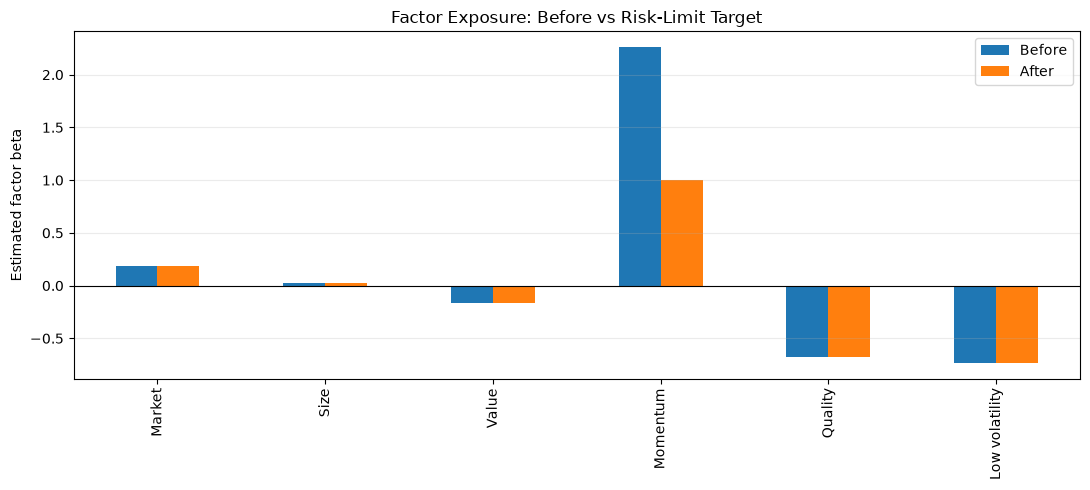

Risk-limit performance matrix:


,Before,Limit,After
Market,+0.184,+0.250,+0.184
Size,+0.024,+0.750,+0.024
Value,-0.163,+0.750,-0.163
Momentum,+2.261,+1.000,+1.000
Quality,-0.675,+0.750,-0.675
Low volatility,-0.731,+0.750,-0.731


Factor stress before: +1.01%
Factor stress after:  +0.21%


In [46]:
# Factor exposure before and after risk limits.
proxy_tickers = ["SPY", "IWM", "IWD", "IWF", "MTUM", "QUAL", "USMV"]
proxy_prices = yf.download(
    proxy_tickers,
    start=prices.index.min().strftime("%Y-%m-%d"),
    end=(prices.index.max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True,
)["Close"]
if isinstance(proxy_prices, pd.Series):
    proxy_prices = proxy_prices.to_frame()
proxy_returns = proxy_prices.pct_change()
factor_returns = pd.DataFrame({
    "Market": proxy_returns["SPY"],
    "Size": proxy_returns["IWM"] - proxy_returns["SPY"],
    "Value": proxy_returns["IWD"] - proxy_returns["IWF"],
    "Momentum": proxy_returns["MTUM"] - proxy_returns["SPY"],
    "Quality": proxy_returns["QUAL"] - proxy_returns["SPY"],
    "Low volatility": proxy_returns["USMV"] - proxy_returns["SPY"],
}).reindex(prices.index)
model_data = pd.concat([portfolio_return.rename("Portfolio"), factor_returns], axis=1).dropna()
factor_names = factor_returns.columns.tolist()
model_matrix = np.column_stack([np.ones(len(model_data)), model_data[factor_names].to_numpy()])
coefficients = np.linalg.lstsq(model_matrix, model_data["Portfolio"].to_numpy(), rcond=None)[0]
before_betas = pd.Series(coefficients[1:], index=factor_names, name="Before")
factor_limits = pd.Series({
    "Market": 0.25, "Size": 0.75, "Value": 0.75,
    "Momentum": 1.00, "Quality": 0.75, "Low volatility": 0.75,
})
after_betas = before_betas.clip(lower=-factor_limits, upper=factor_limits)
factor_before_after = pd.DataFrame({"Before": before_betas, "Limit": factor_limits, "After": after_betas})

factor_before_after[["Before", "After"]].plot(kind="bar", figsize=(11, 5), title="Factor Exposure: Before vs Risk-Limit Target")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Estimated factor beta")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
print("Risk-limit performance matrix:")
display(factor_before_after.style.format("{:+.3f}"))
print(f"Factor stress before: {(before_betas * factor_returns.std()).sum():+.2%}")
print(f"Factor stress after:  {(after_betas * factor_returns.std()).sum():+.2%}")

Risk-limit drawdown optimizer completed in 1.11s.
Objective: minimize full-history maximum drawdown while preserving gross exposure.
Solver status: Optimization terminated successfully
Sign violations: 0
Gross exposure: 200.00% -> 116.33% (minimum allowed: 100.00%)
Top 15 factor-limit weight changes:


,Before,After,Change,Absolute change
LITE,+12.00%,+0.00%,-12.00%,+12.00%
GOOGL,+0.00%,+12.00%,+12.00%,+12.00%
GIS,-12.00%,-0.02%,+11.98%,+11.98%
CHTR,-0.01%,-11.88%,-11.87%,+11.87%
LULU,-0.06%,-11.85%,-11.79%,+11.79%
DDOG,+0.24%,+12.00%,+11.76%,+11.76%
MU,+11.34%,+0.00%,-11.34%,+11.34%
AXON,-11.34%,-0.17%,+11.18%,+11.18%
WDC,+10.21%,+0.00%,-10.21%,+10.21%
PYPL,-10.21%,-0.17%,+10.04%,+10.04%


Factor exposure before and after factor-limit optimizer:


,Before,After,Limit
Market,-0.096,-0.099,+0.250
Size,+0.120,+0.072,+0.750
Value,+0.657,-0.130,+0.750
Momentum,+0.932,+0.263,+1.000
Quality,+0.152,-0.157,+0.750
Low volatility,-2.441,-0.750,+0.750


Factor-limit performance matrix:


,Total return,Annualized return,Annualized volatility,Sharpe,Maximum drawdown,Gross exposure,Turnover vs baseline
Baseline,481.49%,19.44%,29.24%,0.66,-48.31%,200.00%,0.00%
Factor-limit optimizer,387.69%,14.56%,13.52%,1.08,-14.27%,116.33%,249.76%


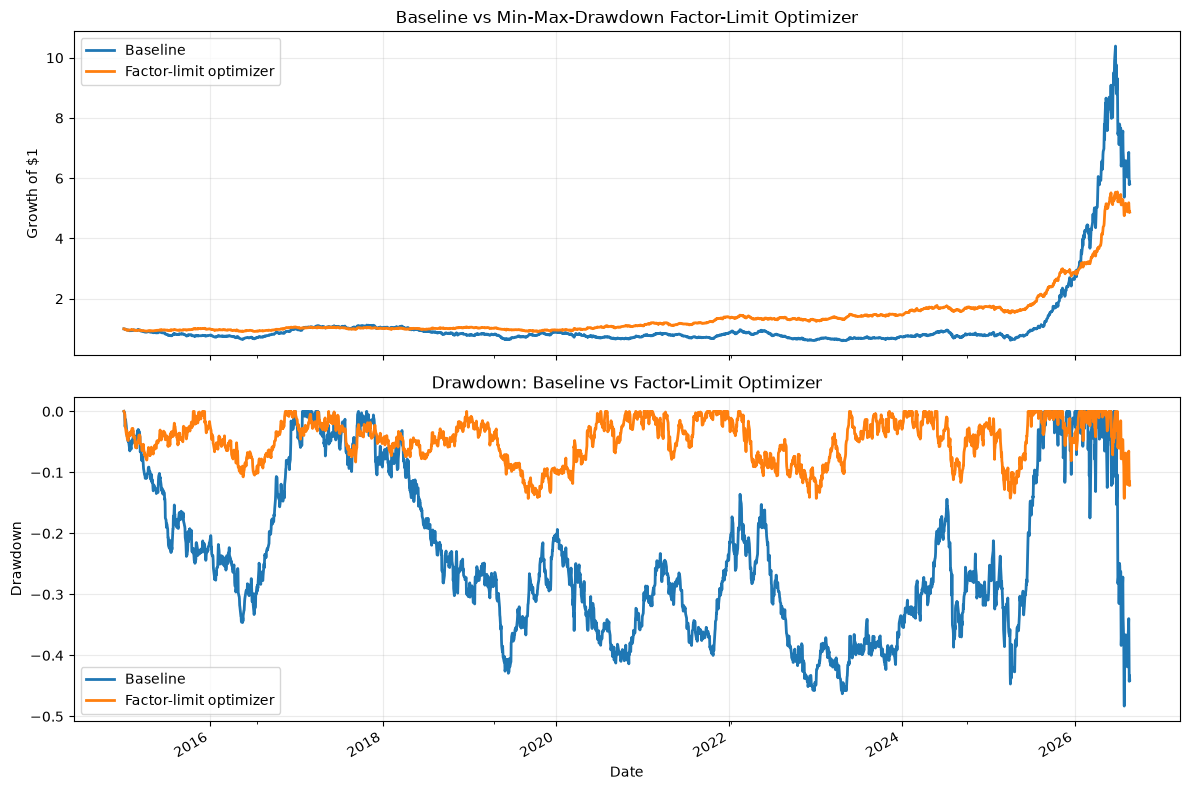

In [47]:
# Close-only risk-limit optimizer: minimize historical maximum drawdown while preserving gross exposure.
from scipy.optimize import minimize
from time import perf_counter

solve_start = perf_counter()
fl_assets = daily_weights.columns.tolist()
fl_returns = returns.reindex(columns=fl_assets).fillna(0.0)
fl_current_weights = daily_weights.iloc[-1].reindex(fl_assets).fillna(0.0)
fl_initial = fl_current_weights.to_numpy()
fl_count = len(fl_assets)

# Estimate all asset factor betas in one matrix regression.
fl_model_data = pd.concat([factor_returns[factor_names], fl_returns], axis=1).dropna()
fl_design = np.column_stack([np.ones(len(fl_model_data)), fl_model_data[factor_names].to_numpy()])
fl_coefficients = np.linalg.lstsq(fl_design, fl_model_data[fl_assets].to_numpy(), rcond=None)[0]
fl_asset_betas = fl_coefficients[1:].T

fl_limits = factor_limits.to_numpy()
fl_initial_net = float(fl_initial.sum())
fl_initial_gross = float(np.abs(fl_initial).sum())
fl_min_gross = 0.50 * fl_initial_gross
fl_position_bound = max(0.12, float(np.abs(fl_initial).max()))
fl_sign_tolerance = 1e-8
fl_weight_bounds = [
    (0.0, fl_position_bound) if weight > fl_sign_tolerance
    else (-fl_position_bound, 0.0) if weight < -fl_sign_tolerance
    else (0.0, 0.0)
    for weight in fl_initial
]
fl_exp_returns = fl_returns.tail(252).mean().to_numpy() * 252
fl_objective_returns = fl_returns.to_numpy()


def fl_drawdown_objective(candidate):
    candidate_daily = fl_objective_returns @ candidate
    candidate_equity = np.cumprod(1.0 + candidate_daily)
    candidate_drawdown = candidate_equity / np.maximum.accumulate(candidate_equity) - 1.0
    max_drawdown = -float(candidate_drawdown.min())
    expected_return = float(candidate @ fl_exp_returns)
    gross_reduction = fl_initial_gross - np.abs(candidate).sum()
    turnover = float(np.abs(candidate - fl_initial).sum())
    # Drawdown is primary; preserve gross exposure and return as tie-breakers.
    return max_drawdown + 0.20 * gross_reduction ** 2 - 0.02 * expected_return + 0.0005 * turnover


def fl_factor_exposure(candidate):
    return candidate @ fl_asset_betas

fl_constraints = [
    {"type": "eq", "fun": lambda candidate: candidate.sum() - fl_initial_net},
    {"type": "ineq", "fun": lambda candidate: fl_initial_gross - np.abs(candidate).sum()},
    {"type": "ineq", "fun": lambda candidate: np.abs(candidate).sum() - fl_min_gross},
    {"type": "ineq", "fun": lambda candidate: fl_limits - fl_factor_exposure(candidate)},
    {"type": "ineq", "fun": lambda candidate: fl_limits + fl_factor_exposure(candidate)},
]

# One warm-started SLSQP solve; close-only bounds prevent opening opposite positions.
fl_result = minimize(
    fl_drawdown_objective,
    fl_initial,
    method="SLSQP",
    bounds=fl_weight_bounds,
    constraints=fl_constraints,
    options={"maxiter": 300, "ftol": 1e-6, "eps": 2e-4, "disp": False},
)
if not fl_result.success:
    raise RuntimeError(f"Risk-limit drawdown optimizer failed: {fl_result.message}")

factor_limit_weights = pd.Series(fl_result.x, index=fl_assets, name="Factor-limit")
fl_before_exposure = pd.Series(fl_initial @ fl_asset_betas, index=factor_names)
fl_after_exposure = pd.Series(fl_result.x @ fl_asset_betas, index=factor_names)
factor_limit_exposure_matrix = pd.DataFrame({"Before": fl_before_exposure, "After": fl_after_exposure, "Limit": factor_limits})

baseline_returns_fl = (fl_returns * fl_current_weights).sum(axis=1).rename("Baseline")
factor_limit_returns = (fl_returns * factor_limit_weights).sum(axis=1).rename("Factor-limit optimizer")
fl_compare_returns = pd.concat([baseline_returns_fl, factor_limit_returns], axis=1).dropna()
fl_compare_equity = (1.0 + fl_compare_returns).cumprod()
fl_compare_drawdown = fl_compare_equity / fl_compare_equity.cummax() - 1.0
factor_limit_performance_matrix = pd.DataFrame({
    "Total return": fl_compare_equity.iloc[-1] - 1.0,
    "Annualized return": fl_compare_returns.mean() * 252,
    "Annualized volatility": fl_compare_returns.std() * np.sqrt(252),
    "Sharpe": (fl_compare_returns.mean() * 252) / (fl_compare_returns.std() * np.sqrt(252)),
    "Maximum drawdown": fl_compare_drawdown.min(),
    "Gross exposure": [np.abs(fl_initial).sum(), np.abs(fl_result.x).sum()],
    "Turnover vs baseline": [0.0, np.abs(fl_result.x - fl_initial).sum()],
}, index=["Baseline", "Factor-limit optimizer"])

fl_top_changes = pd.DataFrame({"Before": fl_current_weights, "After": factor_limit_weights})
fl_top_changes["Change"] = fl_top_changes["After"] - fl_top_changes["Before"]
fl_top_changes["Absolute change"] = fl_top_changes["Change"].abs()
fl_top_changes = fl_top_changes.sort_values("Absolute change", ascending=False)
fl_sign_violations = ((fl_initial * fl_result.x) < -1e-8).sum()
solve_seconds = perf_counter() - solve_start

print(f"Risk-limit drawdown optimizer completed in {solve_seconds:.2f}s.")
print("Objective: minimize full-history maximum drawdown while preserving gross exposure.")
print(f"Solver status: {fl_result.message}")
print(f"Sign violations: {fl_sign_violations}")
print(f"Gross exposure: {fl_initial_gross:.2%} -> {np.abs(fl_result.x).sum():.2%} (minimum allowed: {fl_min_gross:.2%})")
print("Top 15 factor-limit weight changes:")
display(fl_top_changes.head(15).style.format("{:+.2%}"))
print("Factor exposure before and after factor-limit optimizer:")
display(factor_limit_exposure_matrix.style.format("{:+.3f}"))
print("Factor-limit performance matrix:")
display(factor_limit_performance_matrix.style.format({"Total return": "{:.2%}", "Annualized return": "{:.2%}", "Annualized volatility": "{:.2%}", "Sharpe": "{:.2f}", "Maximum drawdown": "{:.2%}", "Gross exposure": "{:.2%}", "Turnover vs baseline": "{:.2%}"}))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fl_compare_equity.plot(ax=axes[0], linewidth=2, title="Baseline vs Min-Max-Drawdown Factor-Limit Optimizer")
axes[0].set_ylabel("Growth of $1")
axes[0].grid(alpha=0.25)
fl_compare_drawdown.plot(ax=axes[1], linewidth=2, title="Drawdown: Baseline vs Factor-Limit Optimizer")
axes[1].set_ylabel("Drawdown")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2. Risk Limit: Beta-Constrained Reallocation With Quality Floors

This section solves for a feasible factor-limit portfolio using constrained optimization.

At each solve, the model enforces factor beta limits and portfolio-structure controls, and it requires the candidate to remain close to baseline quality through return and Sharpe floors.

Mathematically, for factor exposure vector $b(w)$ and limits $L$:

$$
-L \le b(w) \le L
$$

plus portfolio-quality floors:

$$
\mu(w) \ge c_r \cdot \mu(w_0), \qquad S(w) \ge c_s \cdot S(w_0)
$$

where $c_r, c_s$ are floor multipliers. If strict floors are infeasible, the multipliers are relaxed in a predefined sequence. This prevents the factor-limit solution from drifting too far away from baseline return and Sharpe while still forcing beta compliance.

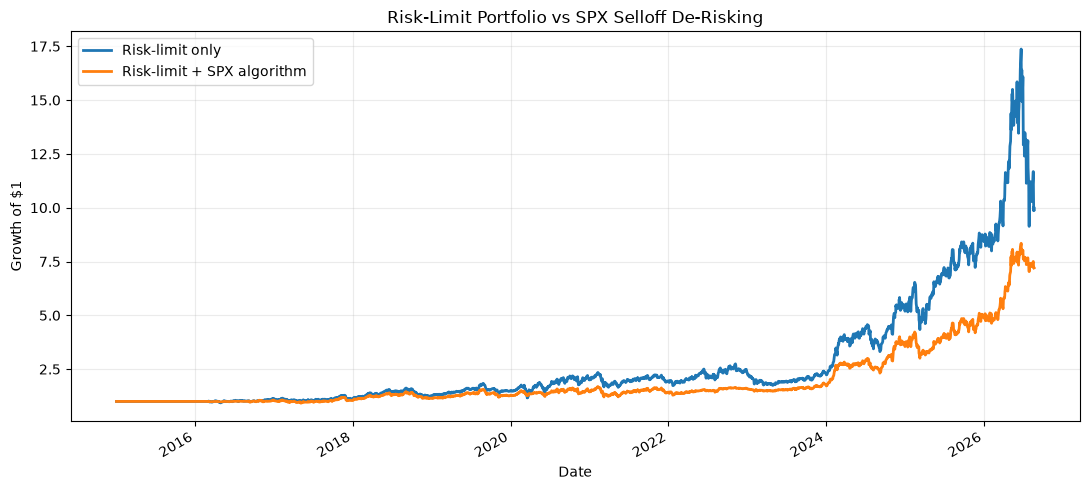

Sell-off de-risking performance matrix:


,Total return,Annualized volatility,Maximum drawdown
Risk-limit only,890.17%,33.91%,-47.43%
Risk-limit + SPX algorithm,620.81%,23.96%,-28.82%


Latest signal:


,SPX drawdown,Volatility ratio,Next-day exposure
Date,,,
2026-08-21 00:00:00,-2.02%,2.34x,25%


In [48]:
# Sell-off signal and before/after performance comparison.
spx_equity_report = (1 + spx_returns.fillna(0.0)).cumprod()
spx_drawdown_report = spx_equity_report / spx_equity_report.cummax() - 1
portfolio_vol_21d = portfolio_return.rolling(21).std() * np.sqrt(252)
vol_baseline = portfolio_vol_21d.rolling(252, min_periods=126).median()
vol_ratio_report = portfolio_vol_21d / vol_baseline

def selloff_multiplier(market_drawdown, volatility_ratio):
    if market_drawdown <= -0.15 or volatility_ratio >= 2.00:
        return 0.25
    if market_drawdown <= -0.10 or volatility_ratio >= 1.50:
        return 0.50
    if market_drawdown <= -0.05 or volatility_ratio >= 1.25:
        return 0.75
    return 1.00

selloff_multiplier_report = pd.Series(
    [selloff_multiplier(drawdown, ratio) for drawdown, ratio in zip(spx_drawdown_report, vol_ratio_report)],
    index=portfolio_return.index,
).shift(1).fillna(1.0)
risk_limit_only_returns = portfolio_return.rename("Risk-limit only")
combined_returns = (portfolio_return * selloff_multiplier_report).rename("Risk-limit + SPX algorithm")
comparison_returns = pd.concat([risk_limit_only_returns, combined_returns], axis=1).dropna()
comparison_equity = (1 + comparison_returns).cumprod()
comparison_drawdown = comparison_equity / comparison_equity.cummax() - 1
selloff_matrix = pd.DataFrame({
    "Total return": comparison_equity.iloc[-1] - 1,
    "Annualized volatility": comparison_returns.std() * np.sqrt(252),
    "Maximum drawdown": comparison_drawdown.min(),
})

comparison_equity.plot(figsize=(11, 5), linewidth=2, title="Risk-Limit Portfolio vs SPX Selloff De-Risking")
plt.ylabel("Growth of $1")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print("Sell-off de-risking performance matrix:")
display(selloff_matrix.style.format("{:.2%}"))
print("Latest signal:")
display(pd.DataFrame({
    "SPX drawdown": spx_drawdown_report,
    "Volatility ratio": vol_ratio_report,
    "Next-day exposure": selloff_multiplier_report,
}).tail(1).style.format({
    "SPX drawdown": "{:.2%}",
    "Volatility ratio": "{:.2f}x",
    "Next-day exposure": "{:.0%}",
}))

# 3. MCTR: Identify the Positions Driving Risk

Once a factor breach is identified, the next question is **which individual positions should be considered for trimming?** MCTR ranks positions using the covariance structure of the current book rather than volatility alone.

For portfolio weights $w$ and annualized covariance matrix $\Sigma$:

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

$$
MCTR_i = \frac{(\Sigma w)_i}{\sigma_p}, \qquad RC_i = w_i MCTR_i
$$

The signed weight matters. Long and short positions can either add to or offset portfolio risk depending on their covariance with the rest of the book. Use MCTR to prioritize individual trims when risk is concentrated; do not interpret it as a forecast of future returns.

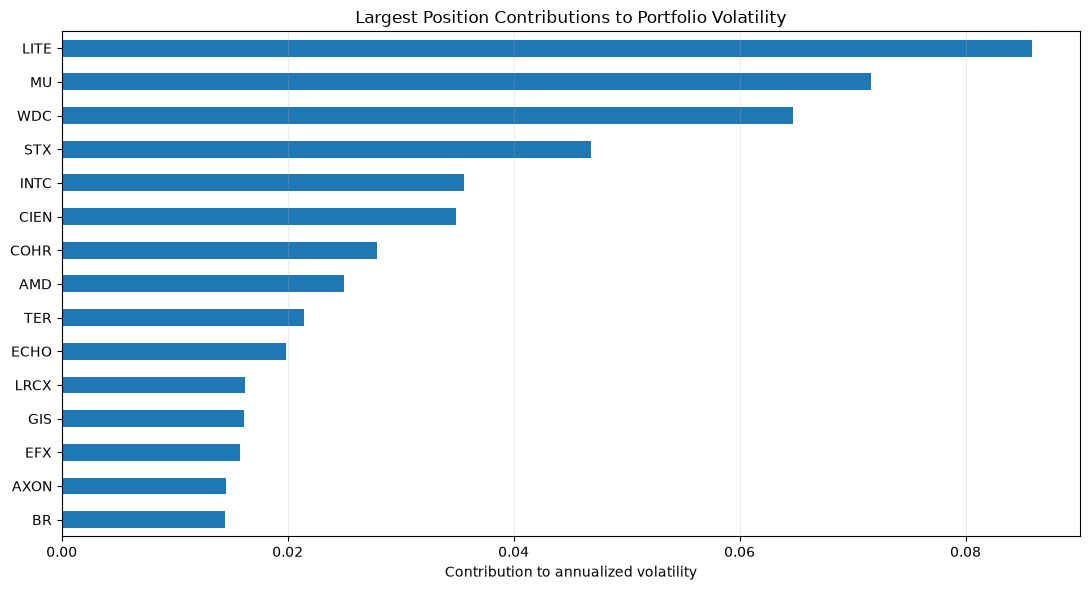

MCTR performance matrix:


,Weight,MCTR,Risk contribution,Risk contribution share
LITE,+12.00%,+0.7153,+0.0858,+12.66%
MU,+11.34%,+0.6319,+0.0717,+10.57%
WDC,+10.21%,+0.6338,+0.0647,+9.54%
STX,+8.17%,+0.5731,+0.0468,+6.91%
INTC,+7.27%,+0.4906,+0.0357,+5.26%
CIEN,+6.43%,+0.5435,+0.0349,+5.15%
COHR,+4.31%,+0.6482,+0.0279,+4.12%
AMD,+5.66%,+0.4410,+0.0250,+3.68%
TER,+3.72%,+0.5776,+0.0215,+3.17%
ECHO,+9.15%,+0.2165,+0.0198,+2.92%


Total portfolio volatility: 67.79%


In [49]:
# Position-level marginal contribution to portfolio volatility.
common_returns = returns.reindex(columns=daily_weights.columns).dropna(how="all").fillna(0.0)
current_weights = daily_weights.iloc[-1].reindex(common_returns.columns).fillna(0.0)
covariance = common_returns.tail(252).cov() * 252
portfolio_variance = float(current_weights.to_numpy() @ covariance.to_numpy() @ current_weights.to_numpy())
portfolio_volatility = np.sqrt(max(portfolio_variance, 0.0))
marginal_volatility = covariance.to_numpy() @ current_weights.to_numpy() / portfolio_volatility
component_contribution = current_weights.to_numpy() * marginal_volatility
mctr = pd.DataFrame({
    "Weight": current_weights,
    "MCTR": marginal_volatility,
    "Risk contribution": component_contribution,
}, index=common_returns.columns)
mctr["Risk contribution share"] = mctr["Risk contribution"] / mctr["Risk contribution"].sum()
mctr = mctr.sort_values("Risk contribution", ascending=False)

mctr.head(15)["Risk contribution"].sort_values().plot(kind="barh", figsize=(11, 6), title="Largest Position Contributions to Portfolio Volatility")
plt.xlabel("Contribution to annualized volatility")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
print("MCTR performance matrix:")
display(mctr.head(15).style.format({
    "Weight": "{:+.2%}",
    "MCTR": "{:+.4f}",
    "Risk contribution": "{:+.4f}",
    "Risk contribution share": "{:+.2%}",
}))
print(f"Total portfolio volatility: {portfolio_volatility:.2%}")

# 4. Constrained Optimization: Choose the Reallocation

MCTR identifies risk contributors, but it does not solve the whole trading decision. The optimizer decides the combination of weight changes that best satisfies the PM's objectives and constraints.

A typical proxy objective is:

$$
\min_w \quad w^T\Sigma w + \lambda\lVert w-w_0\rVert_2^2 + \gamma\lVert B^T w-B^T w_0\rVert_2^2 - \eta\mu^T w
$$

The terms represent portfolio variance, turnover, style drift, and expected-return preference. Constraints can include dollar neutrality, gross exposure, position bounds, factor limits, return floors, liquidity, and protected holdings.

This is why there are many possible reallocation sets. Changing the penalty weights or hard constraints produces a different feasible portfolio for the PM to review.

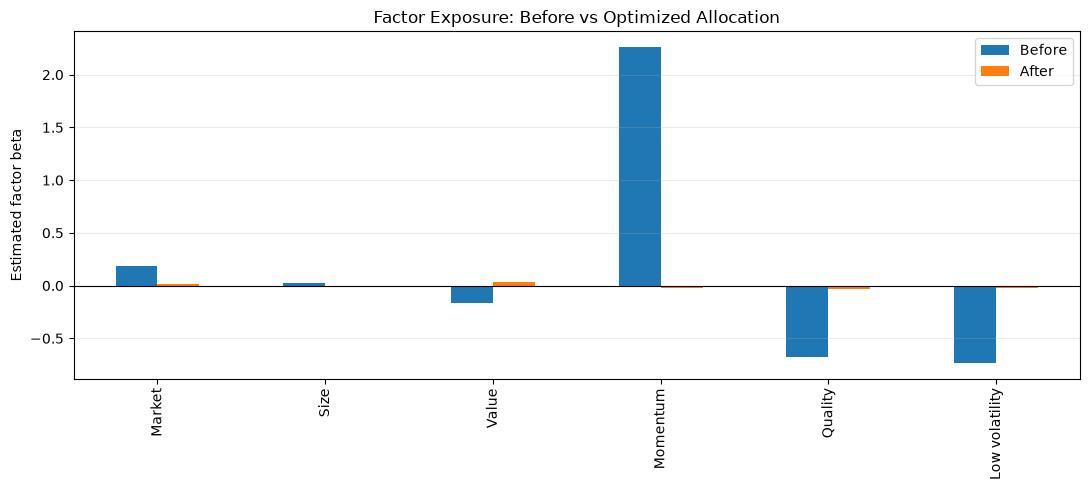

Constrained optimization performance matrix:


,Before,After,Limit
Market,+0.184,+0.013,+0.250
Size,+0.024,-0.006,+0.750
Value,-0.163,+0.032,+0.750
Momentum,+2.261,-0.022,+1.000
Quality,-0.675,-0.036,+0.750
Low volatility,-0.731,-0.018,+0.750


Largest allocation changes selected by the optimizer:


,Before weight,After weight,Weight removed,Absolute change
LITE,+12.00%,+1.32%,-10.68%,+10.68%
MU,+11.34%,+1.07%,-10.27%,+10.27%
WDC,+10.21%,+0.60%,-9.61%,+9.61%
AXON,-11.34%,-2.84%,+8.50%,+8.50%
ECHO,+9.15%,+0.89%,-8.27%,+8.27%
STX,+8.17%,+0.42%,-7.75%,+7.75%
INTC,+7.27%,+0.56%,-6.70%,+6.70%
CIEN,+6.43%,-0.00%,-6.43%,+6.43%
PYPL,-10.21%,-4.90%,+5.30%,+5.30%
COHR,+4.31%,-0.37%,-4.68%,+4.68%


Optimizer converged: True
Gross exposure: 200.00% -> 150.00%
Max factor limit breach: 1.2614 -> 0.0000


In [50]:
# Constrained proxy optimizer for selecting allocation reductions.
from scipy.optimize import minimize

asset_names = current_weights.index.tolist()
asset_covariance = covariance.loc[asset_names, asset_names].to_numpy()
asset_factor_betas = []
for asset in asset_names:
    asset_data = pd.concat([common_returns[asset], factor_returns], axis=1).dropna()
    asset_design = np.column_stack([np.ones(len(asset_data)), asset_data[factor_names].to_numpy()])
    asset_coefficients = np.linalg.lstsq(asset_design, asset_data[asset].to_numpy(), rcond=None)[0]
    asset_factor_betas.append(asset_coefficients[1:])
asset_factor_betas = np.asarray(asset_factor_betas)

initial_weights = current_weights.to_numpy()
gross_limit = min(1.50, np.abs(initial_weights).sum())
position_bound = max(0.12, float(np.abs(initial_weights).max()))

def objective(candidate):
    variance = candidate @ asset_covariance @ candidate
    turnover = np.sum((candidate - initial_weights) ** 2)
    return variance + 0.05 * turnover

def factor_exposure(candidate):
    return candidate @ asset_factor_betas

constraints = [
    {"type": "eq", "fun": lambda candidate: candidate.sum()},
    {"type": "ineq", "fun": lambda candidate: gross_limit - np.abs(candidate).sum()},
    {"type": "ineq", "fun": lambda candidate: factor_limits.to_numpy() - factor_exposure(candidate)},
    {"type": "ineq", "fun": lambda candidate: factor_limits.to_numpy() + factor_exposure(candidate)},
]
optimizer_result = minimize(
    objective,
    initial_weights,
    method="SLSQP",
    bounds=[(-position_bound, position_bound)] * len(asset_names),
    constraints=constraints,
    options={"maxiter": 3000, "ftol": 1e-8},
)
optimized_weights = pd.Series(optimizer_result.x, index=asset_names)
factor_baseline_betas = (
    before_betas.reindex(factor_names)
    if "before_betas" in globals()
    else pd.Series(initial_weights @ asset_factor_betas, index=factor_names)
)
current_book_betas = factor_baseline_betas.copy()
optimized_betas = pd.Series(factor_exposure(optimizer_result.x), index=factor_names)
optimization_matrix = pd.DataFrame({
    "Before": current_book_betas,
    "After": optimized_betas,
    "Limit": factor_limits,
})
allocation_changes = pd.DataFrame({
    "Before weight": current_weights,
    "After weight": optimized_weights,
})
allocation_changes["Weight removed"] = allocation_changes["After weight"] - allocation_changes["Before weight"]
allocation_changes["Absolute change"] = allocation_changes["Weight removed"].abs()
allocation_changes = allocation_changes.sort_values("Absolute change", ascending=False)

optimization_matrix[["Before", "After"]].plot(kind="bar", figsize=(11, 5), title="Factor Exposure: Before vs Optimized Allocation")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Estimated factor beta")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
print("Constrained optimization performance matrix:")
display(optimization_matrix.style.format("{:+.3f}"))
print("Largest allocation changes selected by the optimizer:")
display(allocation_changes.head(15).style.format("{:+.2%}"))
before_breach = np.maximum(np.abs(current_book_betas.to_numpy()) - factor_limits.to_numpy(), 0.0).max()
after_breach = np.maximum(np.abs(optimized_betas.to_numpy()) - factor_limits.to_numpy(), 0.0).max()
print(f"Optimizer converged: {optimizer_result.success}")
print(f"Gross exposure: {np.abs(initial_weights).sum():.2%} -> {np.abs(optimizer_result.x).sum():.2%}")
print(f"Max factor limit breach: {before_breach:.4f} -> {after_breach:.4f}")

# 5. Risk Limit + SPX Drawdown Algorithm

Factor limits address the composition of risk. A market sell-off requires a second control that reduces total exposure quickly, even when the factor composition has not changed.

At each close, the algorithm observes SPX drawdown and the ratio of current realized volatility to its baseline. The next-day exposure multiplier is:

- $0.75$ when SPX drawdown is at least 5% or volatility is at least 1.25 times baseline.
- $0.50$ when SPX drawdown is at least 10% or volatility is at least 1.50 times baseline.
- $0.25$ when SPX drawdown is at least 15% or volatility is at least 2.00 times baseline.

The signal is shifted by one trading day to avoid look-ahead bias. Use this overlay for broad systemic stress; use MCTR and optimization for position-specific or style-specific risk.

Protected holdings: ['LITE']
Risk-limit + PM-constrained optimization:


,Expected annual return,Annualized volatility,Expected Sharpe,Gross exposure
Before PM constraints,192.66%,67.79%,2.84,200.00%
After PM constraints,183.02%,30.68%,5.96,150.00%


Factor exposure before and after:


,Before,After,Limit
Market,+0.184,-0.071,+0.250
Size,+0.024,-0.163,+0.750
Value,-0.163,+0.505,+0.750
Momentum,+2.261,+0.394,+1.000
Quality,-0.675,-0.113,+0.750
Low volatility,-0.731,-0.750,+0.750


Largest allocation changes selected without trimming protected holdings:


,Before weight,After weight,Weight change,Protected
GIS,-12.00%,-0.00%,+12.00%,False
TTD,-0.00%,-12.00%,-12.00%,False
AXON,-11.34%,-0.00%,+11.34%,False
BSX,-0.24%,-10.95%,-10.71%,False
PYPL,-10.21%,-0.00%,+10.21%,False
VST,+0.00%,-9.69%,-9.69%,False
BR,-9.15%,-0.00%,+9.15%,False
BLDR,+0.00%,-8.84%,-8.84%,False
MRNA,+0.00%,+8.30%,+8.30%,False
EFX,-8.17%,-0.00%,+8.17%,False


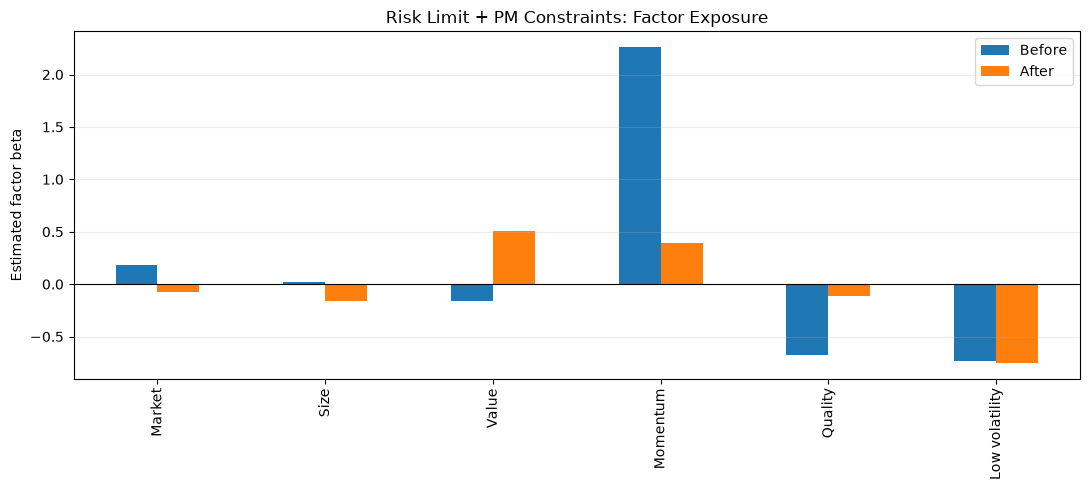

Optimizer converged: True
Expected return floor: 183.02%
Max factor limit breach: 1.2614 -> 0.0000


In [51]:
# PM-constrained optimization: protect required holdings and preserve return quality.
from scipy.optimize import minimize

asset_names = current_weights.index.tolist()
asset_returns = common_returns[asset_names].tail(252).fillna(0.0)
asset_covariance = asset_returns.cov().to_numpy() * 252
asset_expected_returns = asset_returns.mean().to_numpy() * 252
initial_weights = current_weights.to_numpy()

# Replace this example with the names the PM requires to remain in the book.
pm_protected_names = ["LITE"]
protected_names = [name for name in pm_protected_names if name in asset_names]
protected_indices = [asset_names.index(name) for name in protected_names]

baseline_expected_return = float(initial_weights @ asset_expected_returns)
baseline_volatility = float(np.sqrt(initial_weights @ asset_covariance @ initial_weights))
baseline_sharpe = baseline_expected_return / baseline_volatility if baseline_volatility else np.nan
minimum_expected_return = baseline_expected_return * (0.95 if baseline_expected_return >= 0 else 1.05)

# Use auxiliary absolute-weight variables so the gross constraint is smooth for SLSQP.
asset_count = len(asset_names)
initial_candidate = np.concatenate([
    initial_weights * gross_limit / np.abs(initial_weights).sum(),
    np.abs(initial_weights) * gross_limit / np.abs(initial_weights).sum(),
])

# Start from the previous feasible optimizer result when available.
if "optimized_weights" in globals() and len(optimized_weights) == asset_count:
    previous_weights = optimized_weights.reindex(asset_names).to_numpy()
    if np.isfinite(previous_weights).all():
        initial_candidate[:asset_count] = previous_weights
        initial_candidate[asset_count:] = np.abs(previous_weights)

def pm_objective(candidate):
    weights_candidate = candidate[:asset_count]
    variance = weights_candidate @ asset_covariance @ weights_candidate
    turnover = np.sum((weights_candidate - initial_weights) ** 2)
    return variance + 0.05 * turnover

def pm_factor_exposure(candidate):
    return candidate[:asset_count] @ asset_factor_betas

def absolute_weight_constraints(candidate):
    weights_candidate = candidate[:asset_count]
    absolute_weights = candidate[asset_count:]
    return np.concatenate([
        absolute_weights - weights_candidate,
        absolute_weights + weights_candidate,
    ])

pm_constraints = [
    {"type": "eq", "fun": lambda candidate: candidate[:asset_count].sum()},
    {"type": "ineq", "fun": lambda candidate: gross_limit - candidate[asset_count:].sum()},
    {"type": "ineq", "fun": absolute_weight_constraints},
    {"type": "ineq", "fun": lambda candidate: factor_limits.to_numpy() - pm_factor_exposure(candidate)},
    {"type": "ineq", "fun": lambda candidate: factor_limits.to_numpy() + pm_factor_exposure(candidate)},
    {"type": "ineq", "fun": lambda candidate: candidate[:asset_count] @ asset_expected_returns - minimum_expected_return},
]
for protected_index in protected_indices:
    pm_constraints.append({
        "type": "eq",
        "fun": lambda candidate, index=protected_index: candidate[index] - initial_weights[index],
    })

pm_bounds = [(-position_bound, position_bound)] * asset_count + [(0.0, position_bound)] * asset_count
pm_optimizer_result = minimize(
    pm_objective,
    initial_candidate,
    method="SLSQP",
    bounds=pm_bounds,
    constraints=pm_constraints,
    options={"maxiter": 3000, "ftol": 1e-8, "disp": False},
)
if not pm_optimizer_result.success:
    print(f"PM optimizer warning: {pm_optimizer_result.message}")

pm_optimized_weights = pd.Series(pm_optimizer_result.x[:asset_count], index=asset_names)
pm_before_betas = (
    before_betas.reindex(factor_names)
    if "before_betas" in globals()
    else pd.Series(initial_weights @ asset_factor_betas, index=factor_names)
)
pm_optimized_betas = pd.Series(pm_factor_exposure(pm_optimizer_result.x), index=factor_names)
pm_optimized_return = float(pm_optimizer_result.x[:asset_count] @ asset_expected_returns)
pm_optimized_volatility = float(np.sqrt(pm_optimizer_result.x[:asset_count] @ asset_covariance @ pm_optimizer_result.x[:asset_count]))
pm_optimized_sharpe = pm_optimized_return / pm_optimized_volatility if pm_optimized_volatility else np.nan

pm_factor_matrix = pd.DataFrame({
    "Before": pm_before_betas,
    "After": pm_optimized_betas,
    "Limit": factor_limits,
})
pm_allocation_changes = pd.DataFrame({
    "Before weight": current_weights,
    "After weight": pm_optimized_weights,
})
pm_allocation_changes["Weight change"] = (
    pm_allocation_changes["After weight"] - pm_allocation_changes["Before weight"]
)
pm_allocation_changes["Protected"] = pm_allocation_changes.index.isin(protected_names)
pm_allocation_changes = pm_allocation_changes.sort_values(
    "Weight change", key=lambda values: values.abs(), ascending=False
)
pm_performance_matrix = pd.DataFrame({
    "Expected annual return": [baseline_expected_return, pm_optimized_return],
    "Annualized volatility": [baseline_volatility, pm_optimized_volatility],
    "Expected Sharpe": [baseline_sharpe, pm_optimized_sharpe],
    "Gross exposure": [np.abs(initial_weights).sum(), np.abs(pm_optimizer_result.x[:asset_count]).sum()],
}, index=["Before PM constraints", "After PM constraints"])

print("Protected holdings:", protected_names)
print("Risk-limit + PM-constrained optimization:")
display(pm_performance_matrix.style.format({
    "Expected annual return": "{:.2%}",
    "Annualized volatility": "{:.2%}",
    "Expected Sharpe": "{:.2f}",
    "Gross exposure": "{:.2%}",
}))
print("Factor exposure before and after:")
display(pm_factor_matrix.style.format("{:+.3f}"))
print("Largest allocation changes selected without trimming protected holdings:")
display(pm_allocation_changes.head(15).style.format({
    "Before weight": "{:+.2%}",
    "After weight": "{:+.2%}",
    "Weight change": "{:+.2%}",
}))

pm_factor_matrix[["Before", "After"]].plot(
    kind="bar", figsize=(11, 5), title="Risk Limit + PM Constraints: Factor Exposure"
)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Estimated factor beta")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
pm_before_breach = np.maximum(np.abs(pm_before_betas.to_numpy()) - factor_limits.to_numpy(), 0.0).max()
pm_after_breach = np.maximum(np.abs(pm_optimized_betas.to_numpy()) - factor_limits.to_numpy(), 0.0).max()
print(f"Optimizer converged: {pm_optimizer_result.success}")
print(f"Expected return floor: {minimum_expected_return:.2%}")
print(f"Max factor limit breach: {pm_before_breach:.4f} -> {pm_after_breach:.4f}")

# 6. PM Constraints: Protect Required Holdings

An optimizer must reflect the portfolio mandate. If the PM requires a stock to remain in the book, encode that instruction as a hard equality or minimum-weight constraint. The optimizer then removes risk from the remaining tradable positions.

This section combines factor limits, dollar neutrality, a gross-exposure target, position bounds, a return floor, turnover control, and protected holdings. The result is a practical compromise: lower risk without automatically selling the names that provide strategic, fundamental, or client-mandated value.

Use a universal trim when speed matters during a broad sell-off. Use protected optimization when the risk problem is concentrated and the PM has explicit names that cannot be sold.

## PM Readout: How to Choose the Action

The decision is driven by the type of risk event:

- **Broad market shock:** use the universal trim or the SPX/volatility overlay. This is fast and preserves the relative long/short structure.
- **Factor-limit breach:** use the factor-limit optimizer. It reallocates risk until the modeled factor exposures are within policy limits.
- **Concentrated position risk:** use MCTR to identify candidates, then use the optimizer to decide the combined sell-and-buy set.
- **Mandated holdings:** use the protected optimizer. Required names remain unchanged while the rest of the portfolio absorbs the adjustment.
- **Strategy identity is important:** increase the style-drift penalty or impose an explicit factor-drift bound, accepting higher residual volatility if necessary.

No single option dominates. The PM should choose the feasible portfolio that best balances drawdown protection, volatility, Sharpe, factor exposure, turnover, liquidity, and mandate requirements.

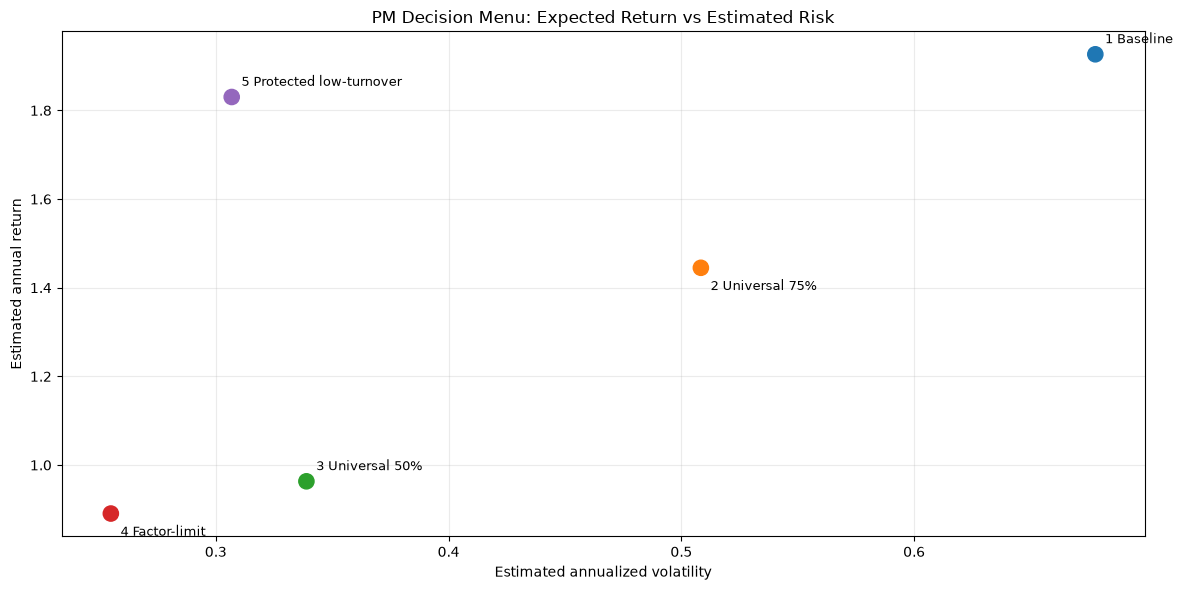

PM decision matrix (use together with the chart):


,Expected annual return,Annualized volatility,Expected Sharpe,Gross exposure,Turnover,Maximum factor limit breach,Factor profile drift,Protected weight change
Label,,,,,,,,
1 Baseline,192.66%,67.79%,2.84,200.00%,0.00%,nan,nan,nan%
2 Universal 75%,144.49%,50.84%,2.84,150.00%,50.00%,nan,nan,nan%
3 Universal 50%,96.33%,33.89%,2.84,100.00%,100.00%,nan,nan,nan%
4 Factor-limit,89.06%,25.49%,3.49,116.33%,249.76%,nan,nan,nan%
5 Protected low-turnover,183.02%,30.68%,5.96,150.00%,258.74%,nan,nan,nan%


In [55]:
# PM-readable risk-return chart with numbered labels matching the matrix.
# Always rebuild the factor-limit option from the latest factor-limit optimizer output.
menu_assets = list(globals().get("menu_assets", current_weights.index.tolist()))
baseline_option = current_weights.reindex(menu_assets).fillna(0.0).to_numpy()
menu_options = {}
if "factor_limit_weights" in globals():
    menu_options["Factor-limit"] = factor_limit_weights.reindex(menu_assets).fillna(0.0).to_numpy()
if "pm_optimized_weights" in globals():
    menu_options["Protected low-turnover"] = pm_optimized_weights.reindex(menu_assets).fillna(0.0).to_numpy()
if "set_solutions" in globals() and "C - Preserve style" in set_solutions:
    menu_options["Protected style-preserving"] = np.asarray(set_solutions["C - Preserve style"])
if not menu_options:
    menu_options["Factor-limit"] = baseline_option

menu_returns_window = common_returns[menu_assets].tail(252).fillna(0.0)
menu_baseline_weights = current_weights.reindex(menu_assets).fillna(0.0)
menu_rows = []

def summarize_menu_option(option_name, option_weights):
    option_series = pd.Series(np.asarray(option_weights), index=menu_assets)
    option_returns = (menu_returns_window * option_series).sum(axis=1)
    option_volatility = option_returns.std() * np.sqrt(252)
    option_expected_return = option_returns.mean() * 252
    option_sharpe = option_expected_return / option_volatility if option_volatility else np.nan
    menu_rows.append({
        "Portfolio": option_name,
        "Expected annual return": option_expected_return,
        "Annualized volatility": option_volatility,
        "Expected Sharpe": option_sharpe,
        "Gross exposure": option_series.abs().sum(),
        "Turnover": np.abs(option_series - menu_baseline_weights).sum(),
        "Maximum factor limit breach": np.nan,
        "Factor profile drift": np.nan,
        "Protected weight change": np.nan,
    })

summarize_menu_option("Baseline", menu_baseline_weights.to_numpy())
summarize_menu_option("Universal 75%", menu_baseline_weights.to_numpy() * 0.75)
summarize_menu_option("Universal 50%", menu_baseline_weights.to_numpy() * 0.50)
for option_name, option_weights in menu_options.items():
    summarize_menu_option(option_name, option_weights)
menu_performance_matrix = pd.DataFrame(menu_rows).set_index("Portfolio")

readout = menu_performance_matrix.reset_index()
readout["Label"] = [
    "1 Baseline", "2 Universal 75%", "3 Universal 50%", "4 Factor-limit",
    "5 Protected low-turnover", "6 Protected style-preserving",
][:len(readout)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    readout["Annualized volatility"], readout["Expected annual return"], s=120,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"][:len(readout)],
)
for index, row in readout.iterrows():
    vertical_offset = 8 if index % 2 == 0 else -16
    ax.annotate(row["Label"], (row["Annualized volatility"], row["Expected annual return"]), xytext=(7, vertical_offset), textcoords="offset points", fontsize=9)
ax.set_title("PM Decision Menu: Expected Return vs Estimated Risk")
ax.set_xlabel("Estimated annualized volatility")
ax.set_ylabel("Estimated annual return")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

pm_readout_matrix = readout.set_index("Label")[[
    "Expected annual return", "Annualized volatility", "Expected Sharpe", "Gross exposure",
    "Turnover", "Maximum factor limit breach", "Factor profile drift", "Protected weight change",
]]
print("PM decision matrix (use together with the chart):")
display(pm_readout_matrix.style.format({
    "Expected annual return": "{:.2%}", "Annualized volatility": "{:.2%}", "Expected Sharpe": "{:.2f}",
    "Gross exposure": "{:.2%}", "Turnover": "{:.2%}", "Maximum factor limit breach": "{:.4f}",
    "Factor profile drift": "{:.3f}", "Protected weight change": "{:.2%}",
}))

# 7. Reallocation Set Generator: From One Answer to a Decision Menu

The optimizer is run repeatedly with different objective priorities to create alternative feasible portfolios. Each set represents a different PM decision:

- Factor risk first: minimize modeled variance and enforce factor limits.
- Low turnover: reduce trading while protecting mandatory holdings.
- Preserve style: penalize changes to the current factor profile.
- Preserve return: retain a minimum share of the current expected return.

For each set, review the expected return, volatility, Sharpe, gross exposure, turnover, factor-profile drift, factor-limit breach, protected-weight change, and the largest reductions and increases. This makes the trade-off visible instead of hiding it inside one optimizer output.

The proxy uses SLSQP with auxiliary absolute-weight variables. A production implementation would typically use quadratic programming for linear constraints, second-order cone programming for explicit volatility or tracking-error limits, and mixed-integer optimization for discrete lots, minimum holdings, cardinality, or buy/sell decisions.

Skipped infeasible set: C - Preserve style (Positive directional derivative for linesearch)
Feasible reallocation sets:


,Expected annual return,Annualized volatility,Expected Sharpe,Gross exposure,Turnover,Factor profile drift,Maximum factor breach,Protected change
Set,,,,,,,,
A - Factor risk first,183.02%,30.63%,5.98,150.00%,260.00%,1.822,0.0000,1.24%
B - Low turnover,183.02%,35.84%,5.11,150.00%,204.51%,1.826,0.0000,0.00%
D - Preserve return,188.58%,45.47%,4.15,150.00%,251.80%,1.701,0.0000,0.00%


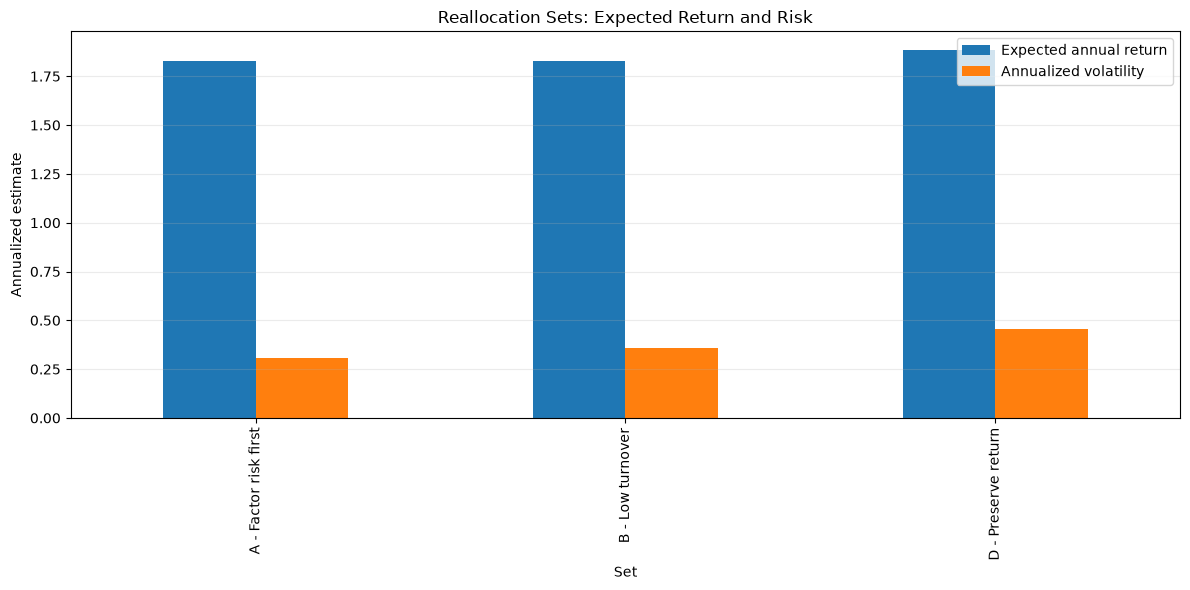

A - Factor risk first: largest reductions and increases


,Before,After,Change
GIS,-12.00%,+0.00%,+12.00%
TTD,-0.00%,-12.00%,-12.00%
BSX,-0.24%,-11.93%,-11.69%
AXON,-11.34%,+0.00%,+11.34%
VST,+0.00%,-10.66%,-10.66%
PYPL,-10.21%,+0.00%,+10.21%
BLDR,+0.00%,-9.74%,-9.74%
BR,-9.15%,+0.00%,+9.15%
CSGP,-0.34%,-8.88%,-8.55%
MRNA,+0.00%,+8.42%,+8.42%


B - Low turnover: largest reductions and increases


,Before,After,Change
GIS,-12.00%,-2.49%,+9.51%
PYPL,-10.21%,-0.89%,+9.32%
TTD,-0.00%,-9.01%,-9.01%
MRNA,+0.00%,+8.66%,+8.66%
AXON,-11.34%,-2.87%,+8.47%
EFX,-8.17%,+0.00%,+8.17%
VEEV,-7.27%,-0.00%,+7.27%
PAYX,-5.66%,+0.00%,+5.66%
AMD,+5.66%,+0.00%,-5.66%
BR,-9.15%,-3.52%,+5.64%


D - Preserve return: largest reductions and increases


,Before,After,Change
GIS,-12.00%,+0.00%,+12.00%
MRNA,+0.00%,+12.00%,+12.00%
META,+0.00%,-12.00%,-12.00%
AMZN,+0.00%,-12.00%,-12.00%
TTD,-0.00%,-12.00%,-12.00%
AXON,-11.34%,+0.00%,+11.34%
PYPL,-10.21%,+0.00%,+10.21%
BR,-9.15%,+0.00%,+9.15%
ECHO,+9.15%,+0.67%,-8.49%
EFX,-8.17%,+0.00%,+8.17%


In [53]:
# Generate alternative feasible reallocation sets for PM selection.
from scipy.optimize import minimize

set_assets = current_weights.index.tolist()
set_count = len(set_assets)
set_initial = current_weights.reindex(set_assets).to_numpy()
set_returns = common_returns[set_assets].tail(252).fillna(0.0)
set_covariance = set_returns.cov().to_numpy() * 252
set_expected_returns = set_returns.mean().to_numpy() * 252
set_factor_betas = asset_factor_betas
set_initial_factors = set_initial @ set_factor_betas
set_initial_return = float(set_initial @ set_expected_returns)
set_gross_target = min(1.50, np.abs(set_initial).sum())
set_position_bound = max(0.12, float(np.abs(set_initial).max()))
set_return_floor = set_initial_return * 0.95
set_protected_names = [name for name in ["LITE"] if name in set_assets]
set_protected_indices = [set_assets.index(name) for name in set_protected_names]

set_start = np.concatenate([
    set_initial * set_gross_target / np.abs(set_initial).sum(),
    np.abs(set_initial) * set_gross_target / np.abs(set_initial).sum(),
])

def set_absolute_constraints(candidate):
    weights_candidate = candidate[:set_count]
    absolute_weights = candidate[set_count:]
    return np.concatenate([absolute_weights - weights_candidate, absolute_weights + weights_candidate])

def solve_reallocation_set(style_penalty, turnover_penalty, return_penalty, protected_indices):
    def objective(candidate):
        weights_candidate = candidate[:set_count]
        variance = weights_candidate @ set_covariance @ weights_candidate
        turnover = np.sum((weights_candidate - set_initial) ** 2)
        style_drift = np.sum((weights_candidate @ set_factor_betas - set_initial_factors) ** 2)
        return variance + turnover_penalty * turnover + style_penalty * style_drift - return_penalty * (weights_candidate @ set_expected_returns)

    def exposures(candidate):
        return candidate[:set_count] @ set_factor_betas

    constraints = [
        {"type": "eq", "fun": lambda candidate: candidate[:set_count].sum()},
        {"type": "ineq", "fun": lambda candidate: set_gross_target - candidate[set_count:].sum()},
        {"type": "ineq", "fun": set_absolute_constraints},
        {"type": "ineq", "fun": lambda candidate: factor_limits.to_numpy() - exposures(candidate)},
        {"type": "ineq", "fun": lambda candidate: factor_limits.to_numpy() + exposures(candidate)},
        {"type": "ineq", "fun": lambda candidate: candidate[:set_count] @ set_expected_returns - set_return_floor},
    ]
    for protected_index in protected_indices:
        constraints.append({
            "type": "eq",
            "fun": lambda candidate, index=protected_index: candidate[index] - set_initial[index],
        })

    return minimize(
        objective,
        set_start,
        method="SLSQP",
        bounds=[(-set_position_bound, set_position_bound)] * set_count + [(0.0, set_position_bound)] * set_count,
        constraints=constraints,
        options={"maxiter": 3000, "ftol": 1e-8},
    )

set_specs = {
    "A - Factor risk first": (0.0, 0.03, 0.0, []),
    "B - Low turnover": (0.0, 1.00, 0.0, set_protected_indices),
    "C - Preserve style": (25.0, 0.20, 0.0, set_protected_indices),
    "D - Preserve return": (2.0, 0.10, 0.50, set_protected_indices),
}
set_solutions = {}
for set_name, specification in set_specs.items():
    result = solve_reallocation_set(*specification)
    if result.success:
        set_solutions[set_name] = result.x[:set_count]
    else:
        print(f"Skipped infeasible set: {set_name} ({result.message})")

set_summary_rows = []
set_trade_tables = {}
for set_name, candidate_weights in set_solutions.items():
    candidate = pd.Series(candidate_weights, index=set_assets)
    candidate_returns = (set_returns * candidate).sum(axis=1)
    candidate_factor_exposure = candidate.to_numpy() @ set_factor_betas
    candidate_volatility = candidate_returns.std() * np.sqrt(252)
    candidate_return = candidate_returns.mean() * 252
    set_summary_rows.append({
        "Set": set_name,
        "Expected annual return": candidate_return,
        "Annualized volatility": candidate_volatility,
        "Expected Sharpe": candidate_return / candidate_volatility if candidate_volatility else np.nan,
        "Gross exposure": candidate.abs().sum(),
        "Turnover": np.abs(candidate - current_weights.reindex(set_assets)).sum(),
        "Factor profile drift": np.linalg.norm(candidate_factor_exposure - set_initial_factors),
        "Maximum factor breach": np.maximum(np.abs(candidate_factor_exposure) - factor_limits.to_numpy(), 0).max(),
        "Protected change": max([abs(candidate.iloc[index] - set_initial[index]) for index in set_protected_indices] or [0.0]),
    })
    changes = pd.DataFrame({"Before": current_weights.reindex(set_assets), "After": candidate})
    changes["Change"] = changes["After"] - changes["Before"]
    set_trade_tables[set_name] = changes.loc[changes["Change"].abs() > 0.001].sort_values("Change", key=lambda values: values.abs(), ascending=False)

set_summary = pd.DataFrame(set_summary_rows).set_index("Set")
print("Feasible reallocation sets:")
display(set_summary.style.format({
    "Expected annual return": "{:.2%}",
    "Annualized volatility": "{:.2%}",
    "Expected Sharpe": "{:.2f}",
    "Gross exposure": "{:.2%}",
    "Turnover": "{:.2%}",
    "Factor profile drift": "{:.3f}",
    "Maximum factor breach": "{:.4f}",
    "Protected change": "{:.2%}",
}))

set_summary[["Expected annual return", "Annualized volatility"]].plot(
    kind="bar", figsize=(12, 6), title="Reallocation Sets: Expected Return and Risk"
)
plt.ylabel("Annualized estimate")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

for set_name, trade_table in set_trade_tables.items():
    print(f"{set_name}: largest reductions and increases")
    display(trade_table.head(12).style.format("{:+.2%}"))

# 8. Final Summary: 2025-2026 PM Decision Report

The final comparison places the baseline, universal trims, optimized reallocation sets, and SPX benchmark on the same 2025-2026 window. The equity chart shows the growth path; the drawdown chart tests whether the de-risking action achieved its primary purpose; the performance matrix reports return, volatility, Sharpe, drawdown, exposure, and turnover; and the factor matrix shows the change in Barra-style betas.

Read the report in this order:

1. Confirm whether the baseline breaches a factor or drawdown risk limit.
2. Decide whether the event is systemic or concentrated.
3. Select universal trim for speed, MCTR plus optimization for concentrated risk, or protected optimization when holdings cannot be sold.
4. Confirm that the selected alternative improves drawdown without violating factor, turnover, liquidity, return, or mandate constraints.

The optimized portfolios are current decision scenarios with in-sample estimates. They are not proof of future performance. The implementation standard is a walk-forward process: estimate at each rebalance date, trade the selected weights, and evaluate only the subsequent out-of-sample period.

Final 2025-2026 performance comparison:


,Historical return 2025-2026,Annualized volatility,Sharpe,Maximum drawdown,Gross exposure,Turnover versus baseline,Sell-off overlay
Portfolio,,,,,,,
Baseline,647.50%,58.47%,2.41,-48.31%,200.00%,0.00%,No
Universal trim 75%,419.03%,31.23%,3.40,-19.45%,150.00%,50.00%,Yes
Universal trim 50%,205.28%,20.82%,3.40,-13.25%,100.00%,100.00%,Yes
Factor-limit,168.53%,17.85%,3.49,-12.14%,116.33%,249.76%,Yes
Protected low-turnover,373.59%,19.88%,4.91,-8.84%,150.00%,258.74%,Yes
A - Factor risk first,374.13%,19.80%,4.94,-9.31%,150.00%,260.00%,Yes
B - Low turnover,419.23%,22.61%,4.60,-6.93%,150.00%,204.51%,Yes
D - Preserve return,395.91%,27.41%,3.73,-10.51%,150.00%,251.80%,Yes
SPX benchmark,29.92%,16.92%,1.03,-18.90%,100.00%,nan%,No


Final 2025-2026 Barra-style factor beta comparison:


,Market,Size,Value,Momentum,Quality,Low volatility
Baseline,-0.255,+0.119,+0.566,+2.135,-0.300,-2.644
Universal trim 75%,-0.261,+0.174,+0.425,+0.673,+0.159,-1.822
Universal trim 50%,-0.174,+0.116,+0.283,+0.449,+0.106,-1.214
Factor-limit,-0.208,+0.087,-0.209,+0.276,-0.516,-0.563
Protected low-turnover,-0.075,-0.081,+0.364,+0.310,+0.150,-0.660
A - Factor risk first,-0.074,-0.092,+0.377,+0.309,+0.147,-0.658
B - Low turnover,-0.085,-0.024,+0.322,+0.439,+0.184,-0.806
D - Preserve return,-0.071,+0.183,+0.470,+0.630,+0.202,-0.938
SPX benchmark,+0.971,+0.036,-0.043,+0.009,+0.082,+0.034


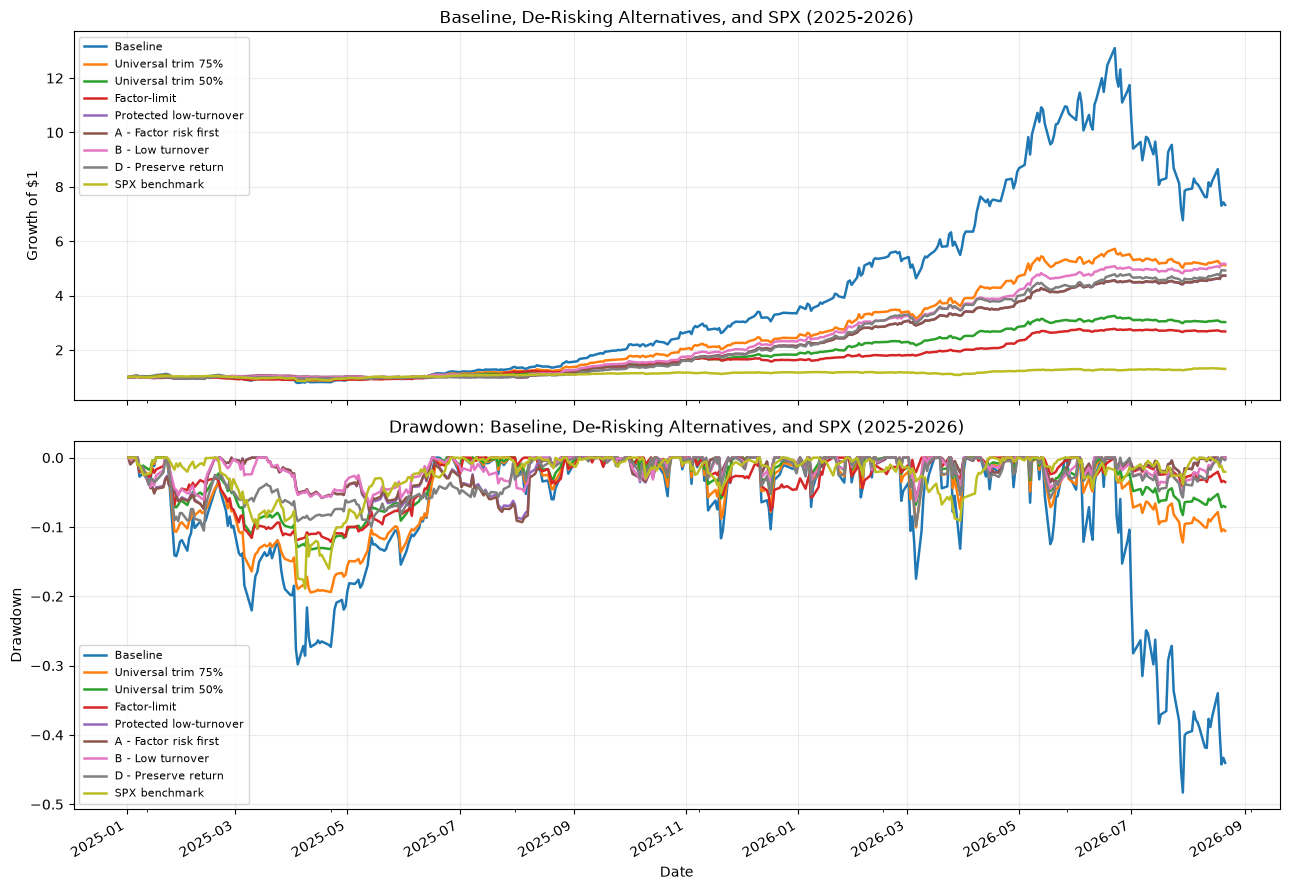

PM rule: use SPX as the market reference; reject any de-risking option that fails to improve drawdown or violates factor, turnover, liquidity, or protected-holding constraints.


In [56]:
# Final 2025-2026 comparison of baseline, de-risking paths, and SPX.
# Always rebuild the factor-limit option from the latest optimizer output.
menu_assets = list(globals().get("menu_assets", current_weights.index.tolist()))
menu_options = {}
if "factor_limit_weights" in globals():
    menu_options["Factor-limit"] = factor_limit_weights.reindex(menu_assets).fillna(0.0).to_numpy()
if "pm_optimized_weights" in globals():
    menu_options["Protected low-turnover"] = pm_optimized_weights.reindex(menu_assets).fillna(0.0).to_numpy()
if "set_solutions" not in globals():
    set_solutions = {}

evaluation_start = "2025-01-01"
evaluation_index = common_returns.index[common_returns.index >= evaluation_start]

final_options = {"Baseline": current_weights.reindex(menu_assets).fillna(0.0).to_numpy()}
final_options["Universal trim 75%"] = final_options["Baseline"] * 0.75
final_options["Universal trim 50%"] = final_options["Baseline"] * 0.50
for option_name, option_weights in menu_options.items():
    if option_name not in final_options:
        final_options[option_name] = np.asarray(option_weights)
for set_name, option_weights in set_solutions.items():
    final_options[set_name] = np.asarray(option_weights)

# Use the same next-day sell-off overlay for every de-risking alternative.
final_overlay = selloff_multiplier_report.reindex(evaluation_index).fillna(1.0)
final_rows = []
final_factor_rows = []
final_equity = {}
for option_name, option_weights in final_options.items():
    option_weights = pd.Series(option_weights, index=menu_assets)
    raw_returns = (common_returns[menu_assets] * option_weights).sum(axis=1)
    option_returns = raw_returns.reindex(evaluation_index).dropna()
    if option_name == "Baseline":
        managed_returns = option_returns.rename(option_name)
    else:
        managed_returns = (option_returns * final_overlay.reindex(option_returns.index).fillna(1.0)).rename(option_name)
    option_equity = (1 + managed_returns).cumprod()
    option_drawdown = option_equity / option_equity.cummax() - 1
    option_volatility = managed_returns.std() * np.sqrt(252)
    option_return = managed_returns.mean() * 252
    option_sharpe = option_return / option_volatility if option_volatility else np.nan
    final_rows.append({
        "Portfolio": option_name,
        "Historical return 2025-2026": option_equity.iloc[-1] - 1,
        "Annualized volatility": option_volatility,
        "Sharpe": option_sharpe,
        "Maximum drawdown": option_drawdown.min(),
        "Gross exposure": option_weights.abs().sum(),
        "Turnover versus baseline": np.abs(option_weights - current_weights.reindex(menu_assets)).sum(),
        "Sell-off overlay": "No" if option_name == "Baseline" else "Yes",
    })
    option_model = pd.concat([managed_returns, factor_returns.reindex(managed_returns.index)], axis=1).dropna()
    option_design = np.column_stack([np.ones(len(option_model)), option_model[factor_names].to_numpy()])
    option_coefficients = np.linalg.lstsq(option_design, option_model[option_name].to_numpy(), rcond=None)[0]
    final_factor_rows.append(pd.Series(option_coefficients[1:], index=factor_names, name=option_name))
    final_equity[option_name] = option_equity

# Add the unscaled SPX benchmark to both summary tables and both plots.
benchmark_returns = spx_returns.reindex(evaluation_index).dropna().rename("SPX benchmark")
benchmark_equity = (1 + benchmark_returns).cumprod()
benchmark_drawdown = benchmark_equity / benchmark_equity.cummax() - 1
benchmark_volatility = benchmark_returns.std() * np.sqrt(252)
benchmark_return = benchmark_returns.mean() * 252
final_rows.append({
    "Portfolio": "SPX benchmark",
    "Historical return 2025-2026": benchmark_equity.iloc[-1] - 1,
    "Annualized volatility": benchmark_volatility,
    "Sharpe": benchmark_return / benchmark_volatility if benchmark_volatility else np.nan,
    "Maximum drawdown": benchmark_drawdown.min(),
    "Gross exposure": 1.0,
    "Turnover versus baseline": np.nan,
    "Sell-off overlay": "No",
})
benchmark_model = pd.concat([benchmark_returns, factor_returns.reindex(benchmark_returns.index)], axis=1).dropna()
benchmark_design = np.column_stack([np.ones(len(benchmark_model)), benchmark_model[factor_names].to_numpy()])
benchmark_coefficients = np.linalg.lstsq(benchmark_design, benchmark_model["SPX benchmark"].to_numpy(), rcond=None)[0]
final_factor_rows.append(pd.Series(benchmark_coefficients[1:], index=factor_names, name="SPX benchmark"))
final_equity["SPX benchmark"] = benchmark_equity

final_performance_matrix = pd.DataFrame(final_rows).set_index("Portfolio")
final_factor_matrix = pd.DataFrame(final_factor_rows)
final_equity = pd.DataFrame(final_equity).dropna()
final_equity = final_equity / final_equity.iloc[0]

print("Final 2025-2026 performance comparison:")
display(final_performance_matrix.style.format({
    "Historical return 2025-2026": "{:.2%}", "Annualized volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Maximum drawdown": "{:.2%}", "Gross exposure": "{:.2%}", "Turnover versus baseline": "{:.2%}",
}))
print("Final 2025-2026 Barra-style factor beta comparison:")
display(final_factor_matrix.style.format("{:+.3f}"))

figure, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
final_equity.plot(ax=axes[0], linewidth=1.8, title="Baseline, De-Risking Alternatives, and SPX (2025-2026)")
axes[0].set_ylabel("Growth of $1")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left", fontsize=8)
final_drawdown = final_equity / final_equity.cummax() - 1
final_drawdown.plot(ax=axes[1], linewidth=1.8, title="Drawdown: Baseline, De-Risking Alternatives, and SPX (2025-2026)")
axes[1].set_ylabel("Drawdown")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

print("PM rule: use SPX as the market reference; reject any de-risking option that fails to improve drawdown or violates factor, turnover, liquidity, or protected-holding constraints.")